In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

In [22]:
df = pd.read_csv(r"C:\Users\cherp\Smart-Energy-Consumption-Analysis-and-Prediction-using-Machine-Learning-with-Device-Level-Insights\data\raw data\smart_home_energy_consumption_large.csv")
print(df.columns)


Index(['Home ID', 'Appliance Type', 'Energy Consumption (kWh)', 'Time', 'Date',
       'Outdoor Temperature (°C)', 'Season', 'Household Size'],
      dtype='object')


In [23]:
# Combine Date and Time into single datetime column
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])

# Sort chronologically
df = df.sort_values('Datetime')

# Reset index
df = df.reset_index(drop=True)

df.head()


,Home ID,Appliance Type,Energy Consumption (kWh),Time,Date,Outdoor Temperature (°C),Season,Household Size,Datetime
0,140,Lights,1.00,00:07,2023-01-01,-5.9,Winter,1,2023-01-01 00:07:00
1,298,Lights,1.09,00:13,2023-01-01,22.0,Winter,1,2023-01-01 00:13:00
2,469,Fridge,0.30,00:24,2023-01-01,-1.2,Winter,3,2023-01-01 00:24:00
3,398,Fridge,0.50,00:26,2023-01-01,35.8,Winter,2,2023-01-01 00:26:00
4,293,Washing Machine,1.12,00:30,2023-01-01,2.7,Winter,3,2023-01-01 00:30:00


In [8]:
scaler = MinMaxScaler(feature_range=(0, 1))
energy_scaled = scaler.fit_transform(df[['Energy Consumption (kWh)']])


In [9]:
def create_sequences(data, time_steps=24):
    X, y = [], []
    for i in range(time_steps, len(data)):
        X.append(data[i-time_steps:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

TIME_STEPS = 24
X, y = create_sequences(energy_scaled, TIME_STEPS)


In [10]:
split_index = int(0.8 * len(X))

X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]


In [11]:
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))


In [12]:
def create_sequences(data, time_steps=24):
    X, y = [], []
    for i in range(time_steps, len(data)):
        X.append(data[i-time_steps:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

TIME_STEPS = 24

X, y = create_sequences(energy_scaled, TIME_STEPS)

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (99976, 24)
y shape: (99976,)


In [13]:
split_index = int(0.8 * len(X))

X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]


In [14]:
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print("X_train shape:", X_train.shape)


X_train shape: (79980, 24, 1)


In [15]:
from tensorflow.keras import Input

model = Sequential([
    Input(shape=(TIME_STEPS, 1)),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])


In [16]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mean_squared_error'
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/30
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 41s 17ms/step - loss: 0.0593 - val_loss: 0.0583
Epoch 2/30
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 41s 18ms/step - loss: 0.0586 - val_loss: 0.0580
Epoch 3/30
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 40s 18ms/step - loss: 0.0585 - val_loss: 0.0580
Epoch 4/30
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 0.0584 - val_loss: 0.0580
Epoch 5/30
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 24s 11ms/step - loss: 0.0584 - val_loss: 0.0580
Epoch 6/30
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 27s 12ms/step - loss: 0.0584 - val_loss: 0.0580
Epoch 7/30
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 28s 12ms/step - loss: 0.0584 - val_loss: 0.0580
Epoch 8/30
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 29s 13ms/step - loss: 0.0584 - val_loss: 0.0580
Epoch 9/30
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 28s 12ms/step - loss: 0.0584 - val_loss: 0.0580
Epoch 10/30
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 29s 13ms/step - loss: 0.0584 - val_loss: 0.0580
Epoch 11/30
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 29s 13ms/step - loss: 0.0584 - val_loss: 0.0580
Epoch 12

In [20]:
y_pred_scaled = model.predict(X_test)

y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_actual = scaler.inverse_transform(y_pred_scaled)

mae = mean_absolute_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))

print("LSTM MAE:", mae)
print("LSTM RMSE:", rmse)

625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
LSTM MAE: 0.8898375655672841
LSTM RMSE: 1.173304247877862


In [24]:
model.save("lstm_model.h5")

In [26]:
from sklearn.linear_model import LinearRegression

# Flatten LSTM input (3D → 2D)
X_train_lr = X_train.reshape(X_train.shape[0], X_train.shape[1])
X_test_lr = X_test.reshape(X_test.shape[0], X_test.shape[1])

# Train Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_lr, y_train)

# Predict
y_pred_lr_scaled = lr_model.predict(X_test_lr)

# Convert back to original scale
y_pred_lr = scaler.inverse_transform(y_pred_lr_scaled.reshape(-1, 1))

# Evaluate
mae_lr = mean_absolute_error(y_test_actual, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test_actual, y_pred_lr))

print("Linear Regression MAE:", mae_lr)
print("Linear Regression RMSE:", rmse_lr)


Linear Regression MAE: 0.8931303196132976
Linear Regression RMSE: 1.173443494815252


In [28]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Model": ["Linear Regression", "LSTM"],
    "MAE": [mae_lr, mae],
    "RMSE": [rmse_lr, rmse]
})
comparison_df

,Model,MAE,RMSE
0,Linear Regression,0.893130,1.173443
1,LSTM,0.889838,1.173304


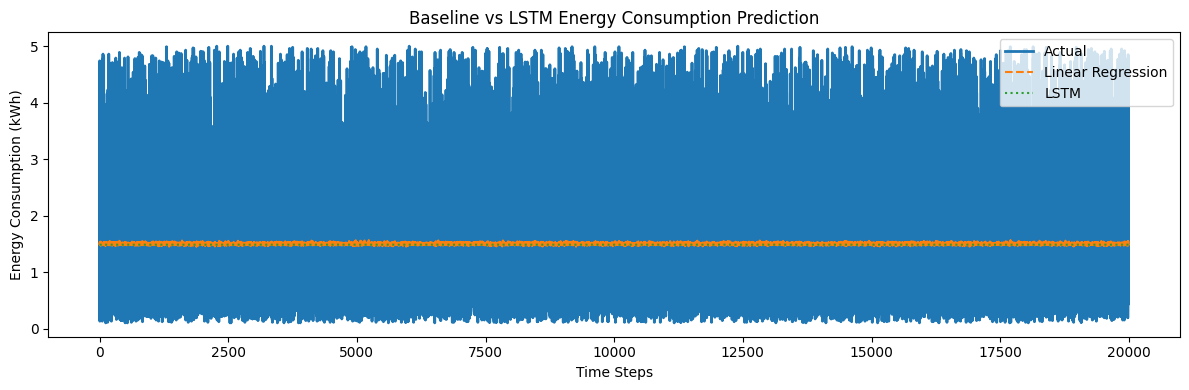

In [29]:
plt.figure(figsize=(12,4))
plt.plot(y_test_actual, label="Actual", linewidth=2)
plt.plot(y_pred_lr, label="Linear Regression", linestyle="--")
plt.plot(y_pred_actual, label="LSTM", linestyle=":")
plt.title("Baseline vs LSTM Energy Consumption Prediction")
plt.xlabel("Time Steps")
plt.ylabel("Energy Consumption (kWh)")
plt.legend()
plt.tight_layout()
plt.show()
